Tested using

*   Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
*   pandas: 2.2.2
*   numpy: 2.0.2
*   matplotlib: 3.10.0
*   scikit-learn: 1.6.1
*   joblib: 1.5.1
*   seaborn: 0.13.2

In [1]:
# Import relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.base import clone
from joblib import Parallel, delayed
import seaborn as sns


In [2]:
# Download the data
!wget -O bank-additional-full.csv https://www.dropbox.com/scl/fi/omkehbrmstg78xv1tynga/bank-additional-full.csv?rlkey=c5uuvoujyg9vzdiysv7ugin61&dl=0

# Import
rawdata = pd.read_csv("bank-additional-full.csv", sep = ";")
print(rawdata.head())

--2025-07-30 21:56:51--  https://www.dropbox.com/scl/fi/omkehbrmstg78xv1tynga/bank-additional-full.csv?rlkey=c5uuvoujyg9vzdiysv7ugin61
Resolving www.dropbox.com (www.dropbox.com)... 162.125.13.18, 2620:100:6031:18::a27d:5112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.13.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc0a3750e13af3ddb5e400c4db5e.dl.dropboxusercontent.com/cd/0/inline/Cucl5BGfVw5QDDHX_RlBS50TtJVva7We-K9_fQ7b-4qpx_hCuyyrwzQkon9szsrOhXceOsu3zy-kFJdoD3L1i2Kat95ViyTf-v_tc6RHqJ6hDZXTUGkH5Of0X5T4lxoOKfSnZ3Sob0paQolJ1UIdreNI/file# [following]
--2025-07-30 21:56:52--  https://uc0a3750e13af3ddb5e400c4db5e.dl.dropboxusercontent.com/cd/0/inline/Cucl5BGfVw5QDDHX_RlBS50TtJVva7We-K9_fQ7b-4qpx_hCuyyrwzQkon9szsrOhXceOsu3zy-kFJdoD3L1i2Kat95ViyTf-v_tc6RHqJ6hDZXTUGkH5Of0X5T4lxoOKfSnZ3Sob0paQolJ1UIdreNI/file
Resolving uc0a3750e13af3ddb5e400c4db5e.dl.dropboxusercontent.com (uc0a3750e13af3ddb5e400c4db5e.dl.dropboxusercontent.com)... 162.1

In [3]:
pd.set_option('future.no_silent_downcasting', True)

# Recode outcome from "yes" and "no" to 1 and 0
rawdata['y'] = rawdata['y'].replace({'no': 0, 'yes': 1})

# Duration is essentially an outcome. It is unknown before the contact and y = 0 => duration = 0
# Drop duration column
rawdata = rawdata.drop(columns = ['duration'])

# Create variable indicating not previously contacted and replace 999's in pdays with 0's
rawdata['never_contacted'] = np.where(rawdata['pdays'] == 999, 1, 0)
rawdata['never_contacted'] = rawdata['never_contacted'].astype('category')
rawdata['pdays'] = np.where(rawdata['pdays'] == 999, 0, rawdata['pdays'])

In [4]:
# Split the data into training (80%) and validation (20%) sets
train, val = train_test_split(rawdata, test_size = 0.2, random_state = 94)

# For use with cross-validation later
cvsplit = KFold(n_splits = 5, shuffle = True, random_state = 94)

In [5]:
# Set data up
X_train = train.drop(columns = ['y'])
y_train = train['y']
X_val = val.drop(columns = ['y'])
y_val = val['y']

# Make sure y_train and y_val are binary type
y_train = y_train.astype(int)
y_val = y_val.astype(int)

In [6]:
# Function to compute drop column variable importance
def drop_column_importance(
    baseline_score,
    X_train,
    y_train,
    X_test,
    y_test,
    metric_fn,
    cloneable_model,
    use_proba=False,
    columns=None,
    n_jobs=-1,
    verbose=0
):
    """
    Calculate feature importance by dropping each column and measuring the performance drop.

    Parameters:
    - baseline_score: Baseline metric score with all features.
    - X_train, y_train: Training data.
    - X_test, y_test: Testing data.
    - metric_fn: Scoring function (e.g., accuracy_score, f1_score, roc_auc_score).
    - cloneable_model: A scikit-learn Pipeline or estimator. Must be cloneable.
    - use_proba: Use predict_proba instead of predict for scoring.
    - n_jobs: Parallel jobs for computing feature importances.
    - verbose: Verbosity level for joblib.

    Returns:
    - List of (feature_name, importance) tuples, sorted by importance.
    """

    def remove_column_from_transformer(transformer, dropped_col):
        new_transformers = []
        for name, trans, cols in transformer.transformers:
            if cols == 'drop' or trans == 'drop':
                new_transformers.append((name, 'drop', cols))
            elif cols == 'passthrough' or trans == 'passthrough':
                new_transformers.append((name, trans, cols))
            else:
                new_cols = [col for col in cols if col != dropped_col]
                if new_cols:
                    new_transformers.append((name, trans, new_cols))
                else:
                    new_transformers.append((name, 'drop', []))
        return ColumnTransformer(new_transformers, remainder=transformer.remainder)

    def compute_importance(col):
        # Drop the column
        X_train_dropped = X_train.drop(columns=[col])
        X_test_dropped = X_test.drop(columns=[col])

        # Clone the model and fit
        model = clone(cloneable_model)

        # If it's a pipeline and uses a ColumnTransformer, rebuild the preprocessor
        if isinstance(model, Pipeline):
            if hasattr(model.named_steps['preprocessor'], 'transformers'):
                preproc = model.named_steps['preprocessor']
                new_preproc = remove_column_from_transformer(preproc, col)
                model.steps[0] = ('preprocessor', new_preproc)

        model.fit(X_train_dropped, y_train)

        # Predict and score
        preds = model.predict_proba(X_test_dropped)[:, 1] if use_proba else model.predict(X_test_dropped)
        dropped_score = metric_fn(y_test, preds)

        # Compute percentage drop in performance
        importance = (baseline_score - dropped_score) / baseline_score
        return col, importance, dropped_score

    if columns is None:
        columns = X_train.columns

    results = Parallel(n_jobs=n_jobs, verbose=verbose)(
        delayed(compute_importance)(col) for col in columns
    )

    return sorted(results, key=lambda x: x[1], reverse=True)


In [7]:
numeric_features = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'never_contacted']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# From exercise showing validation performance, the best random forest we tried
# used min_samples_leaf = 15 and n_estimators = 1000 (though most were very similar)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, random_state=94, n_jobs=-1))
])

# Compute baseline scores
pipeline.fit(X_train, y_train)
baseline_preds = pipeline.predict(X_val)
baseline_predprobs = pipeline.predict_proba(X_val)[:, 1]
baseline_acc = accuracy_score(y_val, baseline_preds)
baseline_auc = roc_auc_score(y_val, baseline_predprobs)
baseline_logloss = log_loss(y_val, baseline_predprobs)
print(f"Baseline Accuracy: {baseline_acc}")
print(f"Baseline AUC: {baseline_auc}")
print(f"Baseline Log Loss: {baseline_logloss}")


Baseline Accuracy: 0.8998543335761107
Baseline AUC: 0.7983858037827664
Baseline Log Loss: 0.27385704334397376


            Feature  Importance  DroppedScore
0         euribor3m    0.001214      0.898762
1           contact    0.000944      0.899005
2          poutcome    0.000809      0.899126
3     cons.conf.idx    0.000540      0.899369
4           default    0.000405      0.899490
5          previous    0.000405      0.899490
6               age    0.000270      0.899612
7    cons.price.idx    0.000270      0.899612
8          campaign    0.000135      0.899733
9             pdays    0.000135      0.899733
10  never_contacted    0.000135      0.899733
11          housing    0.000000      0.899854
12     emp.var.rate    0.000000      0.899854
13            month   -0.000135      0.899976
14      day_of_week   -0.000135      0.899976
15      nr.employed   -0.000135      0.899976
16          marital   -0.000270      0.900097
17             loan   -0.000270      0.900097
18        education   -0.000405      0.900218
19              job   -0.000540      0.900340


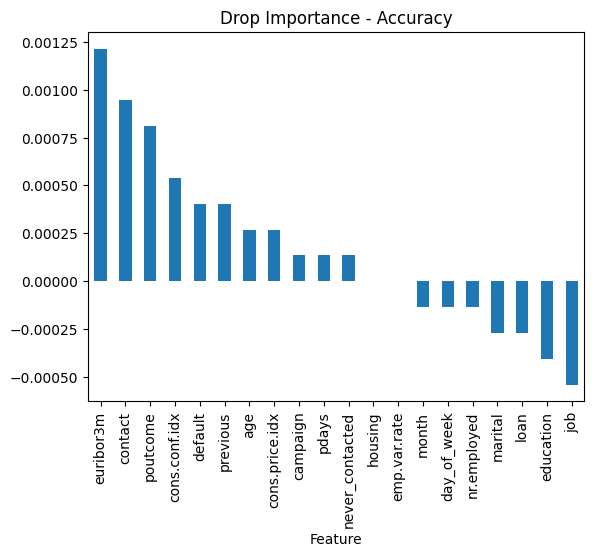

In [8]:
# Drop column importance (accuracy)
dc_acc = drop_column_importance(baseline_acc, X_train, y_train, X_val, y_val, accuracy_score, pipeline)

# Display the results
dc_acc_df = pd.DataFrame(dc_acc, columns=['Feature', 'Importance', 'DroppedScore'])
dc_acc_df = dc_acc_df.sort_values(by='Importance', ascending=False)

print(dc_acc_df)

# Plot the feature importances
dc_acc_df.plot(kind='bar', x='Feature', y='Importance',
                   title='Drop Importance - Accuracy', legend=False)
plt.show()

            Feature  Importance  DroppedScore
19        euribor3m    0.008101      0.276075
18          contact    0.007408      0.275886
17      day_of_week    0.003506      0.274817
16              age    0.002562      0.274559
15         campaign    0.002371      0.274506
14            month    0.001360      0.274230
13    cons.conf.idx    0.001275      0.274206
12   cons.price.idx    0.001144      0.274170
11              job    0.000744      0.274061
10      nr.employed    0.000612      0.274025
9      emp.var.rate    0.000474      0.273987
8   never_contacted    0.000464      0.273984
7          poutcome    0.000450      0.273980
6           default    0.000389      0.273963
5             pdays    0.000338      0.273950
4          previous    0.000254      0.273927
3           housing   -0.000147      0.273817
2              loan   -0.000250      0.273789
1         education   -0.001886      0.273340
0           marital   -0.002811      0.273087


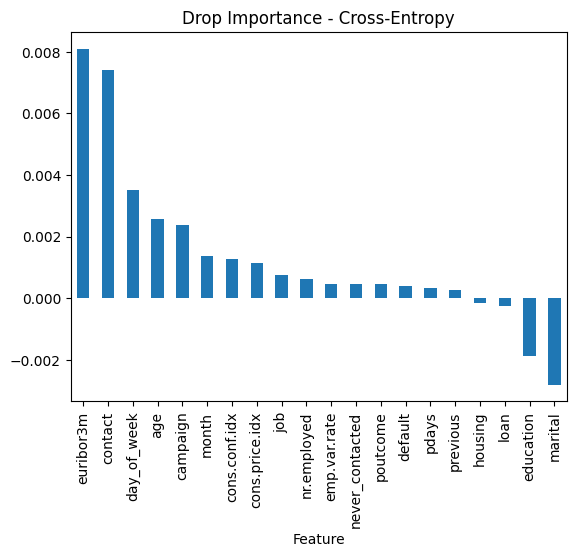

In [9]:
# Drop column importance (cross-entropy)
dc_ce = drop_column_importance(baseline_logloss, X_train, y_train, X_val, y_val, log_loss, pipeline, use_proba=True)

# Display the results
dc_ce_df = pd.DataFrame(dc_ce, columns=['Feature', 'Importance', 'DroppedScore'])
# Multiply importance by -1 because it is a loss
dc_ce_df['Importance'] = -1*dc_ce_df['Importance']
dc_ce_df = dc_ce_df.sort_values(by='Importance', ascending=False)

print(dc_ce_df)

# Plot the feature importances
dc_ce_df.plot(kind='bar', x='Feature', y='Importance',
                   title='Drop Importance - Cross-Entropy', legend=False)
plt.show()

            Feature  Importance  DroppedScore
0         euribor3m    0.007270      0.792581
1           contact    0.004199      0.795033
2       day_of_week    0.002385      0.796482
3               age    0.001823      0.796931
4          campaign    0.001475      0.797208
5               job    0.001385      0.797280
6     cons.conf.idx    0.001103      0.797505
7             month    0.000852      0.797706
8      emp.var.rate    0.000382      0.798081
9    cons.price.idx    0.000230      0.798202
10          default    0.000188      0.798236
11            pdays    0.000157      0.798260
12         previous    0.000050      0.798346
13      nr.employed    0.000009      0.798379
14  never_contacted   -0.000052      0.798428
15         poutcome   -0.000519      0.798801
16             loan   -0.000546      0.798822
17          housing   -0.000698      0.798943
18        education   -0.001304      0.799427
19          marital   -0.002500      0.800382


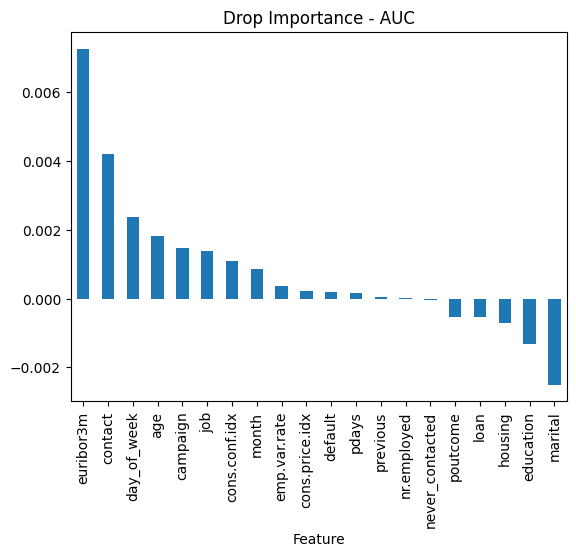

In [10]:
# Drop column importance (auc)
dc_auc = drop_column_importance(baseline_auc, X_train, y_train, X_val, y_val, roc_auc_score, pipeline, use_proba=True)

# Display the results
dc_auc_df = pd.DataFrame(dc_auc, columns=['Feature', 'Importance', 'DroppedScore'])
dc_auc_df = dc_auc_df.sort_values(by='Importance', ascending=False)

print(dc_auc_df)

# Plot the feature importances
dc_auc_df.plot(kind='bar', x='Feature', y='Importance',
                   title='Drop Importance - AUC', legend=False)
plt.show()

            Feature  Importance       Std
19  never_contacted    0.003201  0.000355
7           contact    0.002242  0.000567
18      nr.employed    0.001877  0.000447
14     emp.var.rate    0.001566  0.000471
17        euribor3m    0.001084  0.000425
13         poutcome    0.000874  0.000472
11            pdays    0.000664  0.000174
8             month    0.000473  0.000331
9       day_of_week    0.000340  0.000506
4           default    0.000320  0.000354
16    cons.conf.idx    0.000295  0.000287
10         campaign    0.000174  0.000491
5           housing    0.000121  0.000191
15   cons.price.idx    0.000065  0.000456
12         previous    0.000020  0.000317
2           marital   -0.000057  0.000223
1               job   -0.000061  0.000234
6              loan   -0.000146  0.000176
0               age   -0.000158  0.000259
3         education   -0.000178  0.000327


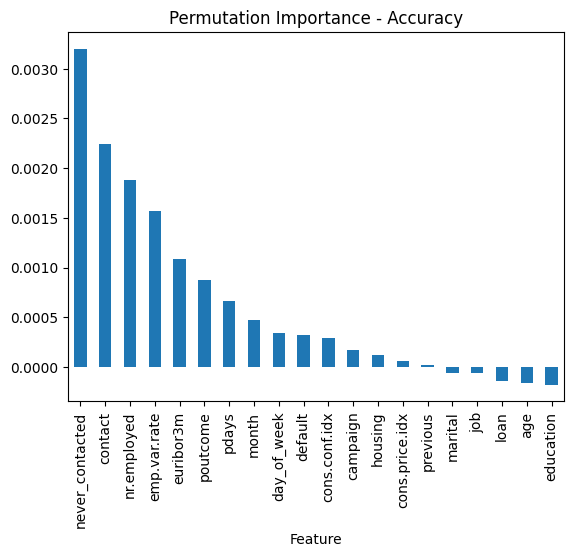

In [11]:
# Now let's look at permutation importance (accuracy)
perm_acc = permutation_importance(
    estimator=pipeline,
    X=X_val,
    y=y_val,
    scoring='accuracy',
    n_repeats=30,
    n_jobs=-1,
    random_state=94
)

perm_acc_df = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': perm_acc.importances_mean,
    'Std': perm_acc.importances_std
}).sort_values('Importance', ascending=False)
print(perm_acc_df)

# Plot the feature importances
perm_acc_df.plot(kind='bar', x='Feature', y='Importance',
                   title='Permutation Importance - Accuracy', legend=False)
plt.show()

            Feature  Importance       Std
18      nr.employed    0.014397  0.001367
17        euribor3m    0.013282  0.001088
14     emp.var.rate    0.011898  0.001086
8             month    0.007063  0.000840
7           contact    0.006639  0.000933
19  never_contacted    0.005747  0.000620
15   cons.price.idx    0.004114  0.000604
16    cons.conf.idx    0.003099  0.000541
13         poutcome    0.001936  0.000434
9       day_of_week    0.001606  0.000434
11            pdays    0.001437  0.000347
0               age    0.001207  0.000409
10         campaign    0.000840  0.000287
1               job    0.000295  0.000237
4           default    0.000294  0.000296
12         previous    0.000183  0.000157
5           housing   -0.000050  0.000256
6              loan   -0.000056  0.000153
3         education   -0.000503  0.000369
2           marital   -0.000584  0.000377


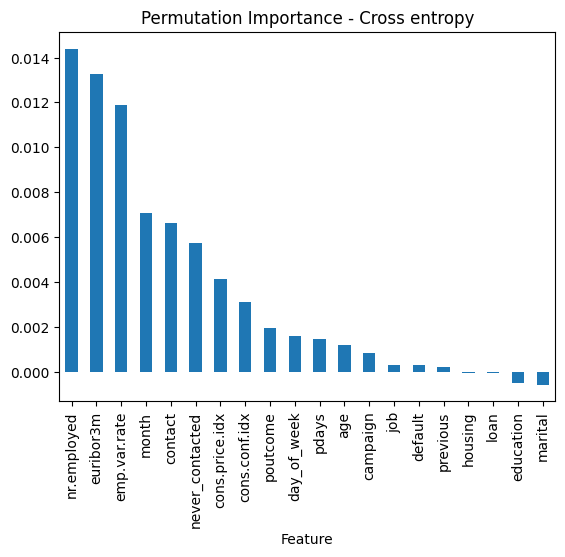

In [12]:
# Now let's look at permutation importance (cross-entropy)
perm_ce = permutation_importance(
    estimator=pipeline,
    X=X_val,
    y=y_val,
    scoring='neg_log_loss',
    n_repeats=30,
    n_jobs=-1,
    random_state=94
)

perm_ce_df = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': perm_ce.importances_mean,
    'Std': perm_ce.importances_std
}).sort_values('Importance', ascending=False)
print(perm_ce_df)

# Plot the feature importances
perm_ce_df.plot(kind='bar', x='Feature', y='Importance',
                   title='Permutation Importance - Cross entropy', legend=False)
plt.show()

            Feature  Importance       Std
14     emp.var.rate    0.019483  0.004041
7           contact    0.019236  0.003665
18      nr.employed    0.016108  0.004105
17        euribor3m    0.013804  0.003530
8             month    0.008473  0.003106
15   cons.price.idx    0.006976  0.002768
16    cons.conf.idx    0.005265  0.002316
19  never_contacted    0.003479  0.001748
0               age    0.003088  0.001775
9       day_of_week    0.003026  0.001577
10         campaign    0.001661  0.001048
11            pdays    0.001608  0.001458
13         poutcome    0.001490  0.001365
1               job    0.000699  0.001133
12         previous    0.000276  0.000591
6              loan   -0.000181  0.000709
5           housing   -0.000495  0.001033
4           default   -0.000563  0.001066
3         education   -0.001403  0.001316
2           marital   -0.001650  0.001405


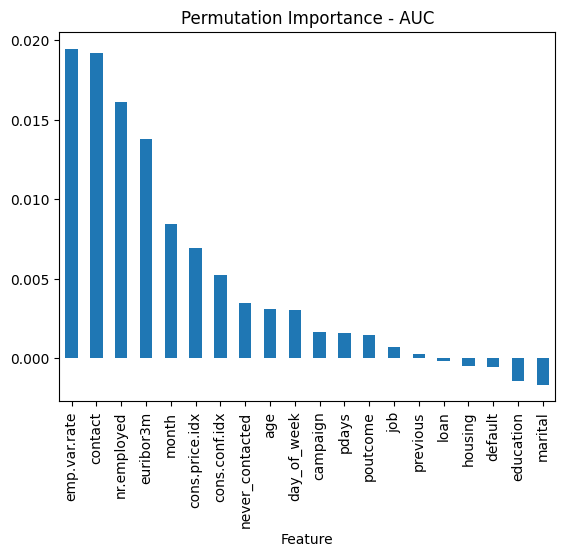

In [13]:
# Now let's look at permutation importance (auc)
perm_auc = permutation_importance(
    estimator=pipeline,
    X=X_val,
    y=y_val,
    scoring='roc_auc',
    n_repeats=30,
    n_jobs=-1,
    random_state=94
)

perm_auc_df = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': perm_auc.importances_mean,
    'Std': perm_auc.importances_std
}).sort_values('Importance', ascending=False)
print(perm_auc_df)

# Plot the feature importances
perm_auc_df.plot(kind='bar', x='Feature', y='Importance',
                   title='Permutation Importance - AUC', legend=False)
plt.show()

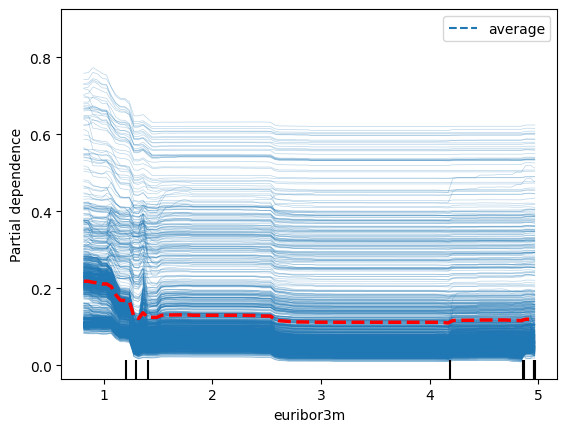

In [14]:
# Finally let's look at a couple of partial dependence plots
pdp_eur = PartialDependenceDisplay.from_estimator(pipeline, X_val, [X_val.columns.get_loc('euribor3m')], kind='both')

for ax in pdp_eur.axes_.ravel():
    lines = ax.get_lines()
    if lines:
        lines[-1].set_color('red')
        lines[-1].set_linewidth(2.5)

plt.show()

In [15]:
# sklearn's built in partial dependence doesn't work well with categorical variables.
def compute_ice_curves(
    pipeline,
    X,
    variable,
    grid=None,
    grid_resolution=100,
    is_categorical=False,
    use_proba=False,
    plot=True
):
    """
    Compute ICE curves (and their average) for a single variable.

    Parameters:
    - pipeline: Fitted sklearn pipeline with a preprocessor and classifier.
    - X: DataFrame of input features (before preprocessing).
    - variable: Name of the variable to vary (string).
    - grid: Optional list of values at which to evaluate ICE.
    - grid_resolution: Number of points for numeric ICE grid (default: 100).
    - is_categorical: If True, treat variable as categorical.
    - use_proba: If True, use predict_proba[:,1] instead of predict().
    - plot: If True, display ICE plot (line plot for numeric, boxplot for categorical).

    Returns:
    - ice_df: DataFrame of shape (n_samples, len(grid)) with ICE values.
    - grid_values: Array of evaluated grid points.
    """
    X = X.copy()
    n_samples = X.shape[0]

    # Determine evaluation grid
    if grid is not None:
        grid_values = np.array(grid)
    elif is_categorical:
        grid_values = np.sort(X[variable].dropna().unique())
    else:
        unique_vals = np.sort(X[variable].dropna().unique())
        if len(unique_vals) <= grid_resolution:
            grid_values = unique_vals
        else:
            grid_values = np.linspace(X[variable].min(), X[variable].max(), grid_resolution)

    # Compute ICE matrix
    ice_matrix = []
    for val in grid_values:
        X_temp = X.copy()
        X_temp[variable] = val
        X_transformed = pipeline.named_steps['preprocessor'].transform(X_temp)
        model = pipeline.named_steps['classifier']
        preds = model.predict_proba(X_transformed)[:, 1] if use_proba else model.predict(X_transformed)
        ice_matrix.append(preds)

    ice_array = np.stack(ice_matrix, axis=1)  # shape: (n_samples, n_grid)
    ice_df = pd.DataFrame(ice_array, columns=grid_values)

    # Plotting
    if plot:
        if is_categorical:
            fig, ax = plt.subplots(figsize=(8, 6))
            ice_long = pd.melt(ice_df.assign(sample=np.arange(n_samples)), id_vars='sample')
            ice_long.columns = ['sample', 'category', 'prediction']
            sns.boxplot(x='category', y='prediction', data=ice_long, ax=ax)
            ax.set_title(f'ICE Box Plot for Categorical Variable: {variable}')
            ax.set_xlabel(variable)
        else:
            fig, ax = plt.subplots(figsize=(8, 6))
            for row in ice_df.itertuples(index=False):
                ax.plot(grid_values, row, color='gray', alpha=0.2)
            ax.plot(grid_values, ice_array.mean(axis=0), color='red', lw=2, label='Average')
            ax.set_title(f'ICE Curves for {variable}')
            ax.set_xlabel(variable)
            ax.set_ylabel('Predicted Response')
            ax.legend()

        plt.tight_layout()
        plt.show()

    return ice_df, grid_values

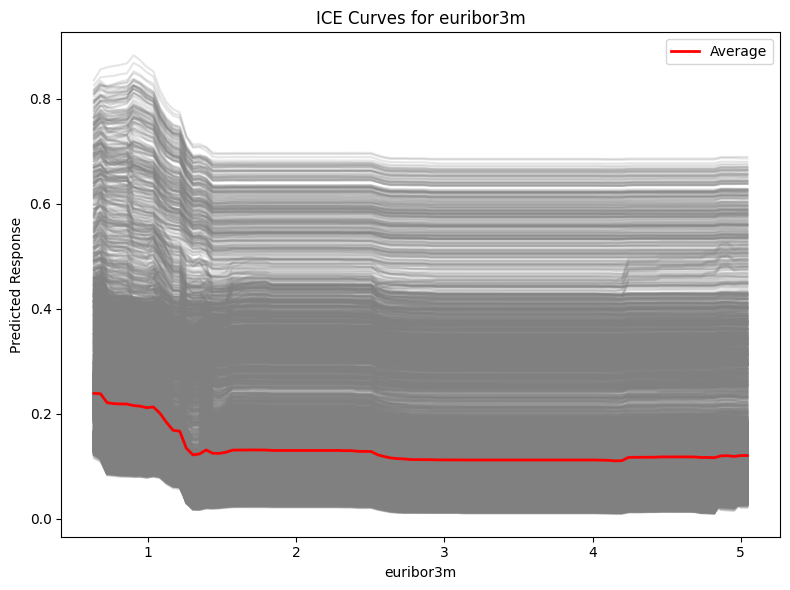

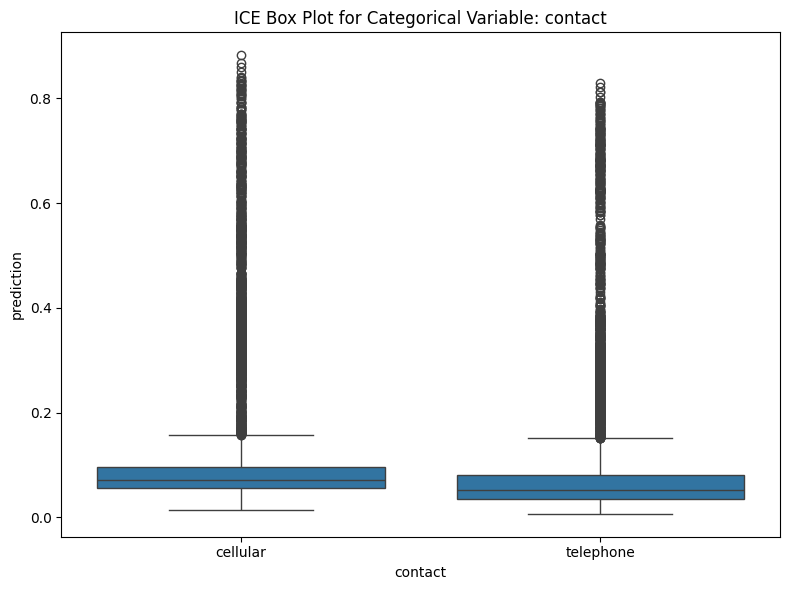

In [16]:
# euribor3m
ice_df, grid = compute_ice_curves(pipeline, X_val, 'euribor3m', use_proba=True)

# contact
ice_cont_df, cont_vals = compute_ice_curves(pipeline, X_val, 'contact', is_categorical=True, use_proba=True)

# job
ice_cat_df, cat_vals = compute_ice_curves(pipeline, X_val, 'job', is_categorical=True, use_proba=True, plot=False)


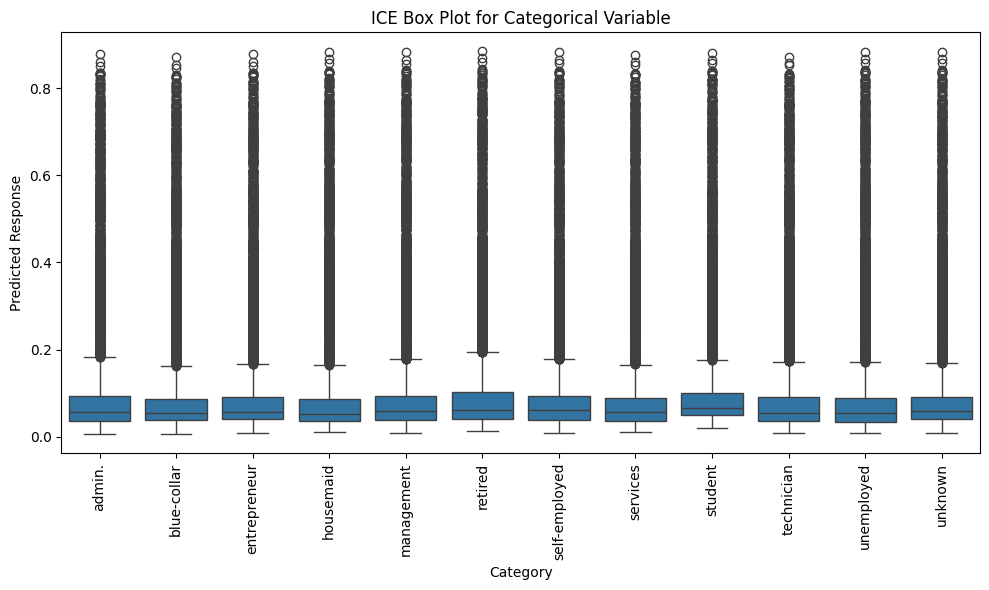

In [17]:
# Reshape ice_cat_df into long format
n_samples = ice_cat_df.shape[0]
ice_long = pd.melt(
    ice_cat_df.assign(sample=np.arange(n_samples)),
    id_vars='sample',
    var_name='category',
    value_name='prediction'
)

# Plot boxplot with rotated x-axis labels
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='category', y='prediction', data=ice_long, ax=ax)
ax.set_title("ICE Box Plot for Categorical Variable")
ax.set_xlabel("Category")
ax.set_ylabel("Predicted Response")
plt.xticks(rotation=90)  # <- rotates labels vertically
plt.tight_layout()
plt.show()